In [1]:
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
from datetime import datetime, timezone
from hyperliquid.hl_candles import build_hl_candles_df
from hyperliquid.hl_funding import build_hl_funding_df, build_hl_8h_funding_df
from binance.binance_funding import build_binance_funding_df, build_binance_basis_df
from binance.binance_candles import build_binance_candles_df

In [2]:
# token info
token_name_binance = "BTCUSDT"
token_name_hl = "BTC"
contract_type = "PERPETUAL"
interval = "1h"
start_time = datetime(2026, 1, 15, 0, 0, 0, tzinfo=timezone.utc) # start date: jan 15th
end_time = datetime(2026, 2, 10, 0, 0, 0, tzinfo=timezone.utc) # end date: feb 10th
limit = 1000

# convert time bounds to unix
start_time_stamp = int(start_time.timestamp() * 1000)
end_time_stamp = int(end_time.timestamp() * 1000)

In [3]:
# create all dataframes
hl_candles_df = build_hl_candles_df(token_name_hl, start_time_stamp, end_time_stamp, interval)
hl_funding_df = build_hl_funding_df(token_name_hl, start_time_stamp, end_time_stamp)
hl_8h_funding_df = build_hl_8h_funding_df(hl_funding_df)
binance_candles_df = build_binance_candles_df(token_name_binance, interval, start_time_stamp, end_time_stamp, limit)
binance_funding_df = build_binance_funding_df(token_name_binance, start_time_stamp, end_time_stamp, limit)
binance_basis_df = build_binance_basis_df(token_name_binance, contract_type, interval, limit, start_time_stamp, end_time_stamp)

In [ ]:
# compute exact basis rate for binance
binance_basis_df["basisRate_exact"] = (binance_basis_df["futuresPrice"] - binance_basis_df["indexPrice"]) / binance_basis_df["futuresPrice"]
print(binance_basis_df)

       indexPrice contractType  basisRate  futuresPrice annualizedBasisRate  \
0    96945.747826    PERPETUAL    -0.0004       96908.0                       
1    96649.249130    PERPETUAL    -0.0004       96613.3                       
2    96443.280435    PERPETUAL    -0.0004       96400.0                       
3    96333.661087    PERPETUAL    -0.0004       96297.2                       
4    95987.333043    PERPETUAL    -0.0005       95943.1                       
..            ...          ...        ...           ...                 ...   
620  70954.451087    PERPETUAL    -0.0006       70912.6                       
621  70757.333043    PERPETUAL    -0.0010       70683.9                       
622  70404.304565    PERPETUAL    -0.0006       70362.4                       
623  70376.030000    PERPETUAL    -0.0006       70334.2                       
624  70142.134130    PERPETUAL    -0.0004       70110.6                       

         basis     pair           timestamp  basisR

In [ ]:
# compute hyperliquid volume multiplier
def hype_volume_multiplier(hl_candles_df: pd.DataFrame):

    # filter df between jan. 15th and jan. 29th
    df_jan15_jan29 = hl_candles_df[
        (hl_candles_df["t"] >= pd.Timestamp("2026-01-15")) &
        (hl_candles_df["t"] <= pd.Timestamp("2026-01-29"))
    ]

    # filter df between jan. 29th and feb. 07th
    df_jan29_feb07 = hl_candles_df[
        (hl_candles_df["t"] >= pd.Timestamp("2026-01-29")) &
        (hl_candles_df["t"] <= pd.Timestamp("2026-02-07"))
    ]

    # compute volume multiplier
    avg_vlm_jan15_jan29 = df_jan15_jan29["ntl_vlm"].mean()
    avg_vlm_jan29_feb07 = df_jan29_feb07["ntl_vlm"].mean()
    volume_multiplier = avg_vlm_jan29_feb07 / avg_vlm_jan15_jan29
    return volume_multiplier

print(hype_volume_multiplier(hl_candles_df))

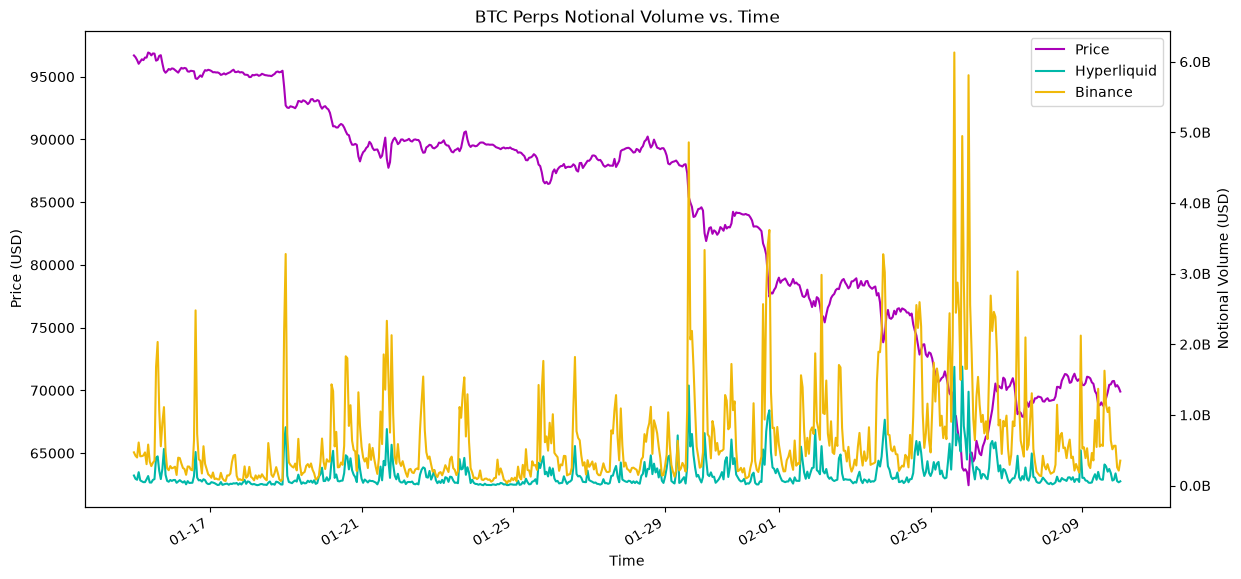

In [ ]:
# plot price and notional volume against time
def plot_price_volume(hl_candles_df: pd.DataFrame, binance_candles_df: pd.DataFrame):

    fig, ax1 = plt.subplots(figsize = (14, 7))
    ax2 = ax1.twinx()

    ax1.plot(hl_candles_df["t"], hl_candles_df["typical_px"], color = "#A900B8", label = "Price")
    ax2.plot(hl_candles_df["t"], hl_candles_df["ntl_vlm"], color = "#00B8A9", label = "Hyperliquid")
    ax2.plot(binance_candles_df["Open Time"], binance_candles_df["Quote Asset Volume"], color = "#F0B90A", label = "Binance")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Price (USD)")
    ax2.set_ylabel("Notional Volume (USD)")

    # formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e9:.1f}B"))

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
    handles1 + handles2,
    labels1 + labels2
    )
    plt.title("BTC Perps Notional Volume vs. Time")
    
plot_price_volume(hl_candles_df, binance_candles_df)

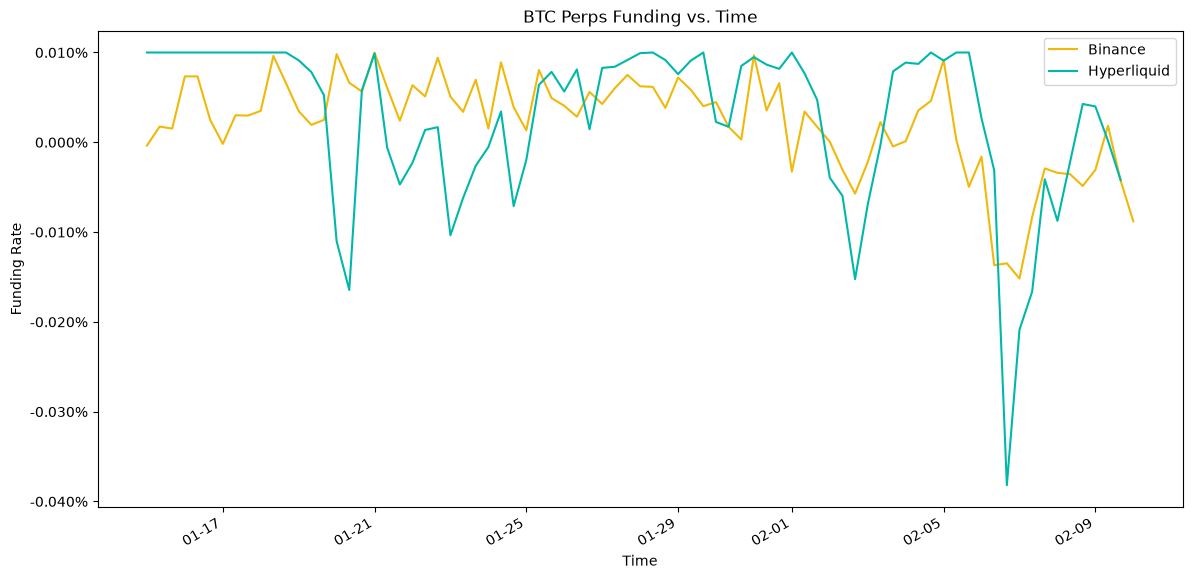

In [ ]:
# plot funding against time (note: 8h intervals)
def plot_funding(hl_8h_funding_df: pd.DataFrame, binance_funding_df: pd.DataFrame):

    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(binance_funding_df["fundingTime"], binance_funding_df["fundingRate"], color = "#F0B90A", label = "Binance")
    ax.plot(hl_8h_funding_df["time"], hl_8h_funding_df["fundingRate"], color = "#00B8A9", label = "Hyperliquid")
    ax.set_xlabel("Time")
    ax.set_ylabel("Funding Rate")

    # formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y*100:.3f}%")
    )
    ax.legend()
    plt.title("BTC Perps Funding vs. Time")

plot_funding(hl_8h_funding_df, binance_funding_df)

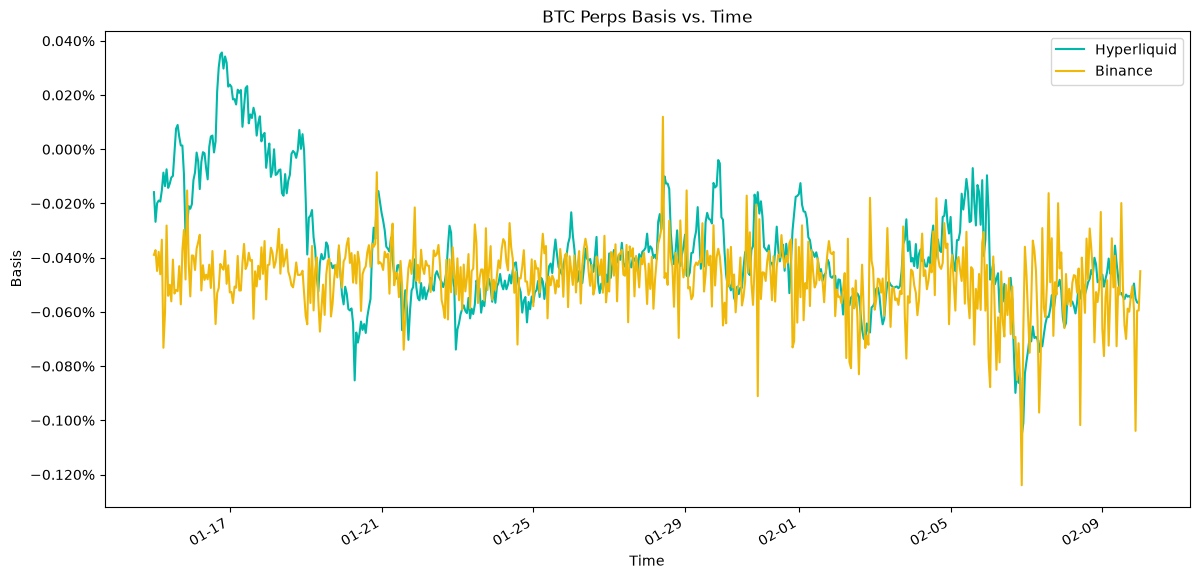

In [ ]:
# plot hyperliquid basis against time (note: hl_funding_df contains basis data, binance basis data is choppy due to rounding)
def plot_basis(hl_funding_df: pd.DataFrame):

    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(hl_funding_df["time"], hl_funding_df["premium"], color = "#00B8A9", label = "Hyperliquid")
    ax.plot(binance_basis_df["timestamp"], binance_basis_df["basisRate_exact"], color = "#F0B90A", label = "Binance")
    ax.set_xlabel("Time")
    ax.set_ylabel("Basis")

    # formatting
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    plt.title("BTC Perps Basis vs. Time")

plot_basis(hl_funding_df)